## Two-pole bessel: the stimulus filter

The HEKA EPC-10 uses a second order Bessel filter in its "stimulus filter", which is applied to voltage steps to reduce capacitative transients.
So we'll have a look at this filter in detail.

First, we'll look at it the conventional way: as a low-pass filter over a _periodic_ signal, analysed in terms of its _frequency response_.

### Frequency response

The standard equation for a 2-pole Bessel is
\begin{align}
H(s) = \frac{3}{s^2 + 3s + 3}
\end{align}

For the _magnitude_ of its frequency response, we find
\begin{align}
|H(i\phi)| = \left| \frac{3}{(i\phi)^2 + 3i\phi + 3} \right| 
           = 3 \left| \frac{1}{3 - \phi^2 + 3\phi i} \right|
\end{align}
To calculate this, we use
\begin{align}
\left| \frac{1}{a + bi} \right|
    = \left| \frac{a - bi}{a^2 + b^2} \right|
    = \sqrt{\frac{a^2 + b^2}{(a^2 + b^2)^2}}
    = \frac{1}{\sqrt{a^2 + b^2}}
\end{align}
for
\begin{align}
|H(i\phi)| = \frac{3}{\sqrt{(3 - \phi^2)^2 + 9\phi^2}}
           = \frac{3}{\sqrt{\phi^4 + 3\phi^2 + 9}}
\end{align}

The frequency at which this filter's gain is $1/\sqrt(2)$ (the 3dB point) is found from:
\begin{align}
\frac{3}{\sqrt{\phi^4 + 3\phi^2 + 9}} &= \frac{1}{\sqrt{2}} \\
\sqrt{\phi^4 + 3\phi^2 + 9} &= 3\sqrt{2}\\
\phi^4 + 3\phi^2 - 9 &= 0 \\
\phi^2 = \frac{-3 \pm \sqrt{9 + 4\cdot9}}{2} &= \frac{3}{2}\left(-1 \pm \sqrt{5} \right) \\
\phi = \pm \sqrt{\frac{3}{2}\left(-1 \pm \sqrt{5} \right)}
\end{align}
By only allowing real and positive numbers, this becomes a single solution, which we'll call $\omega_0$:
\begin{align}
\omega_0 = \sqrt{\frac{3}{2}\left(-1 + \sqrt{5} \right)} \approx 1.36
\end{align}



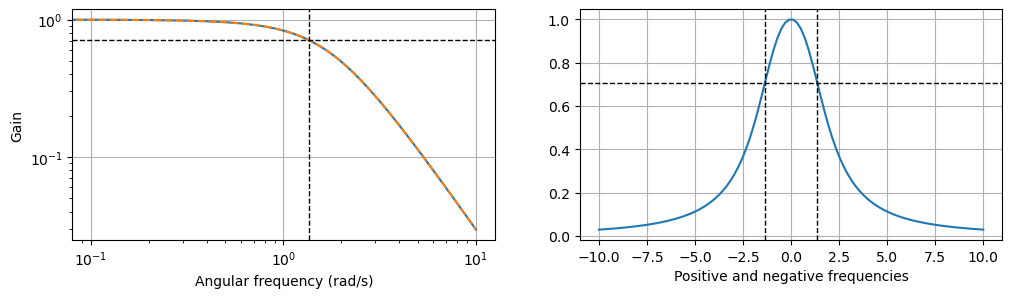

In [14]:
w = np.linspace(0, 10, 100)

fig = plt.figure(figsize=(12, 3))
fig.subplots_adjust(hspace=0.2)

# Make a log-log plot, as used in a Bode diagram
ax = fig.add_subplot(1, 2, 1)
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_ylabel('Gain')
ax.set_xlabel('Angular frequency (rad/s)')
ax.grid()
    
# Plot, letting Numpy work out the absolute value
ax.plot(w, np.abs(3 / ((w*1j)**2 + 3*(w*1j) + 3)))
    
# Plot, using the equation we derived
ax.plot(w, 3 / np.sqrt(w**4 + 3*w**2 + 9), '--')

# Draw lines for w=w0 and gain=1/sqrt(2)
kw = dict(color='k', lw=1, ls='--')
ax.axhline(1 / np.sqrt(2), **kw)
ax.axvline(np.sqrt(3/2 * (np.sqrt(5) - 1)), **kw)

# Show "negative frequencies", in an unscaled plot
w = np.linspace(-10, 10, 100)
ax = fig.add_subplot(1, 2, 2)
ax.set_xlabel('Positive and negative frequencies')
ax.grid()
ax.plot(w, 3 / np.sqrt(w**4 + 3*w**2 + 9))
ax.axhline(1 / np.sqrt(2), **kw)
ax.axvline(np.sqrt(3/2 * (np.sqrt(5) - 1)), **kw)
ax.axvline(-np.sqrt(3/2 * (np.sqrt(5) - 1)), **kw)
plt.show()

Now, we scale the filter to place this point at a user-defined cut-off frequency $\omega_c=10\,\text{kHz}=2\cdot10^4/\pi\,\text{rad}/\text{s}$:

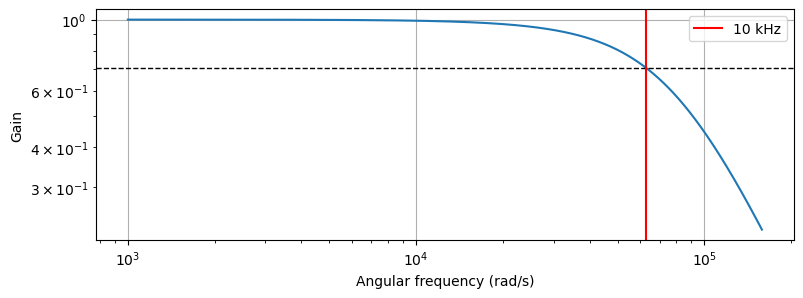

In [15]:
w = np.logspace(3, 5.2, 1000)
w0 = np.sqrt(3 / 2 * (np.sqrt(5) - 1))
z = w * w0 / (2e4 * np.pi)

fig = plt.figure(figsize=(9, 3))
ax = fig.add_subplot()
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_ylabel('Gain')
ax.set_xlabel('Angular frequency (rad/s)')
ax.grid()
ax.plot(w, 3 / np.sqrt(z**4 + 3*z**2 + 9))
kw = dict(color='k', lw=1, ls='--')
ax.axhline(1 / np.sqrt(2), **kw)
ax.axvline(2e4 * np.pi, color='r', label='10 kHz')
ax.legend()
plt.show()

### Step response and rise time

The HEKA stimulus filter is described as having a [rise time](https://en.wikipedia.org/wiki/Rise_time) of either 20$\mu$s or 2$\mu$s.
See e.g. the EPC-10 hardware manual:

> Two degrees of filtering, specified as the rise times (time from 10% to 90% of the amplitude of a step change) are available in the
software: 2 µs, which is the minimum required to avoid non-linearity in the internal circuitry, and 20 µs, which is preferable for all but the fastest measurements, to reduce the capacitive transients

To find the transfer function scalings for these settings, we start by working out the _step response_:


From [Appendix A2](./2-laplace-and-filters) we get the step function and its Laplace transform
\begin{align}
u(t) = \delta(t) && U(s) = \frac{1}{s}
\end{align}
for output
\begin{align}
Y(s) = H(s)U(s) = \frac{3}{s(s^2 + 3s + 3)}
\end{align}

To solve this, we split into partial coefficients while keeping the second-order term together:

\begin{align}
Y(s) = \frac{3}{s(s^2 + 3s + 3)} 
     = \frac{A}{s} + \frac{B + Cs}{s^2 + 3s + 3}
\end{align}

\begin{align}
3 &= A(s^2 + 3s + 3) + Bs + Cs^2 \\
  &= (A + C)s^2 + (3A + B)s + 3A
\end{align}
\begin{align}
A = 1 && B = -3 && C = -1
\end{align}

\begin{align}
Y(s) = \frac{1}{s} + \frac{-3 - s}{s^2 + 3s + 3}
     = \frac{1}{s} - \frac{3 + s}{s^2 + 3s + 3}
\end{align}

To save time, we could also have [asked a website](https://www.wolframalpha.com/input?i=partial+fractions+3%2F%28s%28s%5E2+%2B+3s+%2B+3%29%29) or used [SymPy](https://docs.sympy.org/latest/modules/polys/reference.html#sympy.polys.partfrac.apart):

In [16]:
from sympy.polys.partfrac import apart
from sympy.abc import s

apart(3 / (s * (s**2 + 3 * s + 3)))

-(s + 3)/(s**2 + 3*s + 3) + 1/s

To get the inverse transform, we can write this in pole-zero form:
\begin{align}
Y(s) = \frac{1}{s} - \frac{3 + s}{(s + \sigma - i\omega)(s + \sigma + i\omega)},
&& \sigma = 3/2,
&& \omega = \sqrt{3}/2
\end{align}

This has the advantage that we can look up the standard solution, e.g. in [Appendix A2](./2-laplace-and-filters)
\begin{align}
F(s) &= \frac{C_1 + C_2 s}{(s + \sigma - i\omega)(s + \sigma + i\omega)} \\
f(t) &= \left( \frac{C_1 - C_2\sigma}{\omega}e^{-\sigma t} \sin(\omega t) + C_2 e^{-\sigma t} \cos(\omega t) \right) \theta(t)
\end{align}

to find
\begin{align}
y(t) &= \theta(t) - \left( \frac{C_1 - C_2\sigma}{\omega}e^{-\sigma t} \sin(\omega t) + C_2 e^{-\sigma t} \cos(\omega t) \right) \theta(t) \\
&= \theta(t) \left[1 - \frac{3 - 3/2}{\sqrt{3}/2}e^{-3/2t} \sin(\sqrt{3}/2 t) + e^{-3/2 t} \cos(\sqrt{3}/2 t) \right] \\
&= \theta(t) \left[1 - (\sqrt{3} \sin(\sqrt{3}/2 t) + \cos(\sqrt{3}/2 t))e^{-3/2t} \right]
\end{align}

Let's plot it:

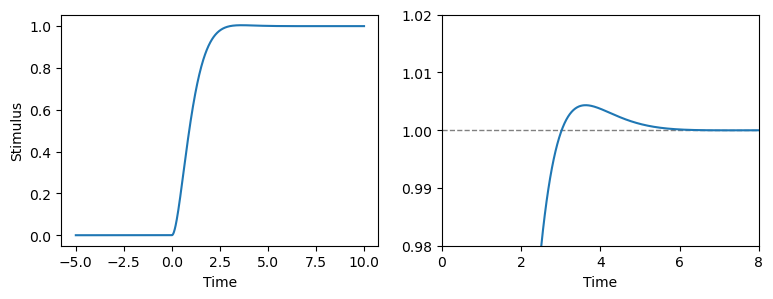

In [17]:
t = np.linspace(-5, 10, 1000)

def bessel2_step(t):
    theta = 1 * (t >= 0)
    s = np.sqrt(3)
    return theta * (1 - (s * np.sin(s/2*t) + np.cos(s/2*t)) * np.exp(-3/2*t))

y = bessel2_step(t)

fig = plt.figure(figsize=(9, 3))
fig.subplots_adjust(hspace=0.2)
ax = fig.add_subplot(1, 2, 1)
ax.update(dict(xlabel='Time', ylabel='Stimulus'))
ax.plot(t, y)
ax = fig.add_subplot(1, 2, 2)
ax.set_xlabel('Time')
ax.axhline(1, color='grey', ls='--', lw=1)
ax.plot(t, y)
ax.set_xlim(0, 8)
ax.set_ylim(0.98, 1.02)
plt.show()

This looks good! And we can see the near lack of overshoot that makes Bessel filters popular.

We can use the equations above to work out the rise time, but it's probably not a lovely expression so we'll just do it numerically:

0.2999218750000007 0.10001114060500294
1.8783203124999999 0.8999978202201413


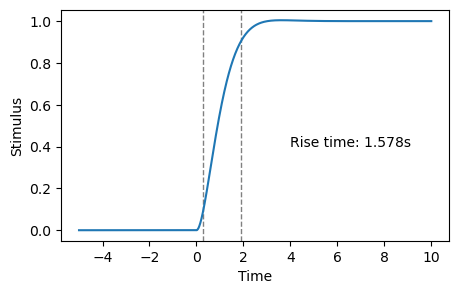

In [18]:
from scipy.optimize import fmin
t10 = fmin(lambda x: (bessel2_step(x) - 0.1)**2, 0.1, disp=False)[0]
t90 = fmin(lambda x: (bessel2_step(x) - 0.9)**2, 2, disp=False)[0]
print(t10, bessel2_step(t10))
print(t90, bessel2_step(t90))
fig = plt.figure(figsize=(5, 3))
ax = fig.add_subplot()
ax.update(dict(xlabel='Time', ylabel='Stimulus'))
ax.axvline(t10, color='grey', ls='--', lw=1)
ax.axvline(t90, color='grey', ls='--', lw=1)
ax.plot(t, y)
ax.text(4, 0.4, f'Rise time: {t90 - t10:.4}s')
plt.show()

To emulate a rise time of 20$\mu$s, we scale $t$:

0.0038124999999999843 0.10029671636557969
0.0238125 0.8996055239892486


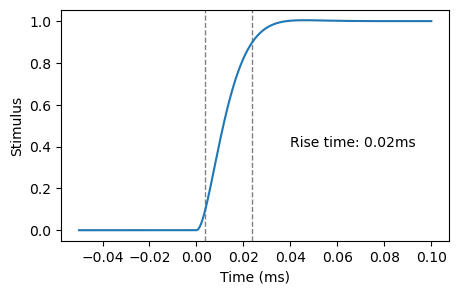

In [19]:
t = np.linspace(-0.05, 0.1, 1000)

def bessel2_step(t, x):
    theta = 1 * (t >= 0)
    s = np.sqrt(3)
    t = t / 2 * x
    return theta * (1 - (s * np.sin(s*t) + np.cos(s*t)) * np.exp(-3*t))

f = 78.8
y = bessel2_step(t, f)

t10 = fmin(lambda x: (bessel2_step(x, f) - 0.1)**2, 0.01, disp=False)[0]
t90 = fmin(lambda x: (bessel2_step(x, f) - 0.9)**2, 0.02, disp=False)[0]
print(t10, bessel2_step(t10, f))
print(t90, bessel2_step(t90, f))

fig = plt.figure(figsize=(5, 3))
ax = fig.add_subplot()
ax.update(dict(xlabel='Time (ms)', ylabel='Stimulus'))
ax.axvline(t10, color='grey', ls='--', lw=1)
ax.axvline(t90, color='grey', ls='--', lw=1)
ax.plot(t, y)
ax.text(0.04, 0.4, f'Rise time: {t90 - t10:.4}ms')
plt.show()

### Does this match what we measure?

The HEKA EPC-9 has a [paper describing its hardware](), which contains a nice block diagram (Fig 1).
This shows us that

1. The stimulus filter is applied to the command potential before any other additions (e.g. Cm and Rs compensation)
2. The "V monitor" is read directly from the stimulus filter output, again without any interference from other components.

As a result, we should be able to see the effects of the stimulus filter on a recorded "V monitor" signal.
Here's a recording made using an EPC-10:

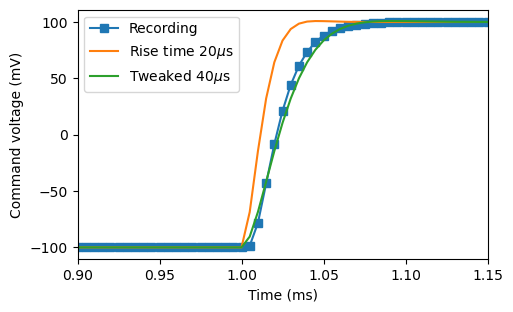

In [20]:
import myokit
d = myokit.DataLog.load('./res/stimulus-filter.zip')
d = d.npview()

fig = plt.figure(figsize=(5, 3))
fig.subplots_adjust(0.14, 0.15, 0.96, 0.98)
ax = fig.add_subplot()
ax.set_xlabel('Time (ms)')
ax.set_ylabel('Command voltage (mV)')

ax.plot(d.time(), d['v20us'], 's-', label='Recording')

t = d.time()
y = -100 + 200 * bessel2_step(t - 1, 78.8)
ax.plot(t, y, label=r'Rise time 20$\mu$s')
y = -100 + 200 * bessel2_step(t - 1, 78.8 / 2)
ax.plot(t, y, label=r'Tweaked 40$\mu$s')

ax.legend()
ax.set_xlim(0.9, 1.15)
plt.show()

In [21]:
f = 40
t10 = fmin(lambda x: (bessel2_step(x, f) - 0.1)**2, 0.01, disp=False)[0]
t90 = fmin(lambda x: (bessel2_step(x, f) - 0.9)**2, 0.02, disp=False)[0]
assert abs(bessel2_step(t10, f) - 0.1) < 1e-2
assert abs(bessel2_step(t90, f) - 0.9) < 1e-2
print(t90 - t10)

0.03943750000000005


It seems the rise time is roughly twice what is advertised.

### Can we use a first order approximation for the stimulus filter?

The 2-pole Bessel was easy enough to implement, but having 2 state variables is maybe a bit over the top.
What does it look like if we approximate with a single-order filter?

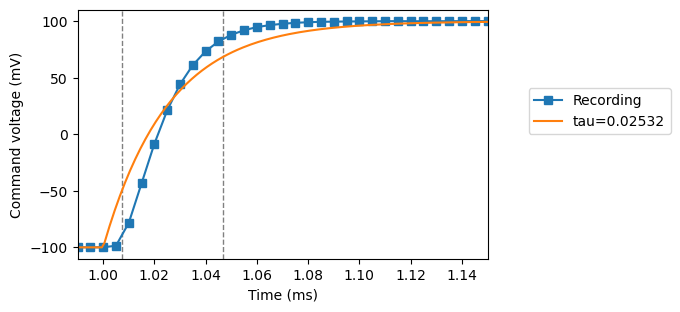

In [22]:
def y(t, tau):
    t[t < 0] = 0
    return 100 + (-100 - 100) * np.exp(-t / tau)

tau = fmin(lambda tau: np.sum((y(d.time() - 1, tau) - d['v20us'])**2), 0.02, disp=False)[0]

fig = plt.figure(figsize=(5, 3))
fig.subplots_adjust(0.14, 0.15, 0.96, 0.98)
ax = fig.add_subplot()
ax.set_xlabel('Time (ms)')
ax.set_ylabel('Command voltage (mV)')

ax.axvline(1 + t10, color='grey', lw=1, ls='--')
ax.axvline(1 + t90, color='grey', lw=1, ls='--')
ax.plot(d.time(), d['v20us'], 's-', label='Recording')

t = np.linspace(0, 2, 2000)
ax.plot(t, y(t - 1, tau), label=f'tau={tau:.4}')
ax.legend(loc=(1.1, 0.5))
ax.set_xlim(0.99, 1.15)
plt.show()

This is not far off at all, and any discrepancies only last for 0.1ms. Compared to e.g. fast-capacitance compensation, it is unlikely that approximating as first order will cause any problems.